In [1]:
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
# import geopandas as gpd
# from shapely.geometry import Point
import glob

from tqdm import tqdm
import os
import shutil
import tempfile
import logging
import geopandas as gpd
import rioxarray as rxr

In [2]:
# LDD direction convention (PCRaster):
# 7 8 9
# 4 5 6
# 1 2 3
# For each direction, what is the (row_offset, col_offset) of the downstream neighbour?
# e.g. direction 1 means flow goes to bottom-left → downstream is at (+1, -1)

# Inverse: for each neighbour position, which LDD value points TO the current cell?
# neighbour at (-1, -1) has direction 3 if it flows to us
# neighbour at (-1,  0) has direction 2
# neighbour at (-1, +1) has direction 1
# neighbour at ( 0, -1) has direction 6
# neighbour at ( 0, +1) has direction 4
# neighbour at (+1, -1) has direction 9
# neighbour at (+1,  0) has direction 8
# neighbour at (+1, +1) has direction 7

# (row_offset, col_offset) -> LDD value that points toward current cell
UPSTREAM_DIRS = {
    (-1, -1): 3,
    (-1,  0): 2,
    (-1, +1): 1,
    ( 0, -1): 6,
    ( 0, +1): 4,
    ( 1, -1): 9,
    ( 1,  0): 8,
    ( 1, +1): 7,
}

def cutmaps_own(ldd_array, lon_array, lat_array, station_lon, station_lat):
    """
    Trace upstream from station pixel through LDD to get catchment mask.
    Returns a 2D boolean array (same shape as ldd_array).
    """
    # find nearest pixel to station coordinates
    col = np.argmin(np.abs(lon_array - station_lon))
    row = np.argmin(np.abs(lat_array - station_lat))
    # print(f"  Station pixel: row={row}, col={col}, lon={lon_array[col]:.3f}, lat={lat_array[row]:.3f}")

    nrows, ncols = ldd_array.shape
    mask = np.zeros((nrows, ncols), dtype=bool)

    # BFS upstream flood-fill
    queue = [(row, col)]
    mask[row, col] = True

    while queue:
        r, c = queue.pop()
        for (dr, dc), upstream_val in UPSTREAM_DIRS.items():
            nr, nc = r + dr, c + dc
            if 0 <= nr < nrows and 0 <= nc < ncols:
                if not mask[nr, nc] and ldd_array[nr, nc] == upstream_val:
                    mask[nr, nc] = True
                    queue.append((nr, nc))

    return mask


### Setup

In [3]:
BASE_FILE = Path.cwd () / "../glofas5_hydrobot.csv"
# Folder with static attributes
DIR_STATIC = Path("/mnt/eos_rw/projects/FLOODS-RIVER/schafti/02_GloFAS_EFAS/GloFAS/GloFASv5/static_maps/GloFASv5_staticmaps_consolidated_March2026/GloFASv5_static_maps_reanalysis/")
# Folder with parameter attributes
DIR_PARS = Path("/mnt/eos_rw/projects/FLOODS-RIVER/schafti/02_GloFAS_EFAS/GloFAS/GloFASv5/static_maps/GloFASv5_parametermaps/")

# Output Dir
DIR_OUT = Path.cwd () / "../results"

# Base File
glofas5_base_info = pd.read_csv(BASE_FILE)

In [4]:
# station list
cal_stations = glofas5_base_info[["grid_x","grid_y", "ID"]].values
if not (DIR_STATIC / "cal_stations.txt").exists():
    with open(DIR_STATIC / "cal_stations.txt", "w") as f:
        for x, y, id_ in cal_stations:
            f.write(f"{x:.3f}  {y:.3f}\t{int(id_)}\n")

In [5]:
# load GloFASv5 Parameters
glofas_pars = xr.open_mfdataset(sorted(glob.glob(str(DIR_PARS / "*.nc"))), combine="by_coords")
# glofas_pars = glofas_pars.load()

### Paramter divergence between catchments

In [22]:
glofas5_base_info.columns

Index(['ID', 'name', 'basin', 'river', 'provider', 'iso', 'DrainageArea_prov',
       'DrainageArea_LDD', 'lat', 'lon', 'grid_x', 'grid_y', 'SourceGlo',
       'GlofasV5', 'Obs_start', 'Obs_end', 'Split_date_CALstart', 'KGEmod',
       'JSD', 'Function', 'Region', 'elv_mean', 'elv_median', 'laii_mean',
       'laii_median', 'laif_mean', 'laif_median', 'gradient_mean',
       'gradient_median', 'lusemask_mean', 'lusemask_median',
       'soildepth1_f_mean', 'soildepth1_f_median', 'soildepth1_o_mean',
       'soildepth1_o_median', 'fracforest_mean', 'fracforest_median',
       'fracirrigated_mean', 'fracirrigated_median', 'fracother_mean',
       'fracother_median', 'ksat1_f_mean', 'ksat1_f_median', 'ksat1_o_mean',
       'ksat1_o_median', 'tp_mean_annual', 'tp_std_interann', 'tp_seasonality',
       'eT0_mean_annual', 'eT0_std_interann', 'eT0_seasonality', 'ta_mean',
       'ta_std_interann', 'ta_seasonality', 'aridity_index',
       'param_CalChanMan1', 'param_CalChanMan3', 'param_GwLo

In [ ]:
# ─────────────────────────────────────────────
# 1. Daten laden & stations_df vorbereiten
# ─────────────────────────────────────────────

ds_ldd    = xr.open_dataset(DIR_STATIC / "ldd_repaired.nc")
ds_uparea = xr.open_dataset(DIR_STATIC / "upArea_repaired_correctedmetadata_3000.nc")
uparea_array = ds_uparea["Band1"].values   # explizit Band1
ldd_array = ds_ldd["Band1"].values   # explizit Band1

# Koordinaten — anpassen falls deine Dim-Namen anders heissen
lon_array = ds_ldd["lon"].values if "lon" in ds_ldd.coords else ds_ldd["x"].values
lat_array = ds_ldd["lat"].values if "lat" in ds_ldd.coords else ds_ldd["y"].values

# stations_df aufbauen
stations_df = glofas5_base_info[["ID", "grid_x", "grid_y"]].copy()
stations_df.columns = ["station_id", "lon", "lat"]
stations_df = stations_df.dropna().reset_index(drop=True)

# Pixel-Koordinaten und Uparea vorberechnen
stations_df["_col"] = stations_df["lon"].apply(lambda x: int(np.argmin(np.abs(lon_array - x))))
stations_df["_row"] = stations_df["lat"].apply(lambda y: int(np.argmin(np.abs(lat_array - y))))

rows = stations_df["_row"].values.astype(int)
cols = stations_df["_col"].values.astype(int)
stations_df["_uparea"] = uparea_array[rows, cols]

print(f"Stations: {len(stations_df)}")
print(stations_df[["station_id","lon","lat","_uparea"]].describe())

# ─────────────────────────────────────────────
# 2. Connectivity Graph bauen (Option A)
# ─────────────────────────────────────────────

def build_direct_downstream_graph(stations_df, ldd_array, uparea_array, lon_array, lat_array):
    """
    Für jede Station: finde direkten Downstream-Nachbarn.
    Sortiert nach uparea → erster Mask-Treffer = direkter Downstream.
    """
    stations_sorted = stations_df.sort_values("_uparea").reset_index(drop=True)
    n = len(stations_sorted)
    
    mask_cache  = {}   # station_id → bool mask
    downstream  = {}   # station_id → downstream station_id or None
    
    for i, station in tqdm(stations_sorted.iterrows(), total=n, desc="Building graph"):
        sid      = station.station_id
        row_s    = int(station._row)
        col_s    = int(station._col)
        ua_s     = station._uparea
        
        # Nur Kandidaten mit größerer Uparea, aufsteigend sortiert
        candidates = stations_sorted[stations_sorted._uparea > ua_s]
        
        direct_ds = None
        for _, cand in candidates.iterrows():
            cid = cand.station_id
            if cid not in mask_cache:
                mask_cache[cid] = cutmaps_own(
                    ldd_array, lon_array, lat_array, cand.lon, cand.lat) # Cutmaps fuer EZG Grenzen
            
            if mask_cache[cid][row_s, col_s]:
                direct_ds = cid
                break  # kleinste Uparea die current enthält = direkter DS
        
        downstream[sid] = direct_ds
        
        # RAM Management: Mask der aktuellen Station kann weg
        # wenn sie nicht mehr als Kandidat gebraucht wird
        # (sie ist bereits processed, alle späteren haben größere uparea)
        mask_cache.pop(sid, None)
    
    return downstream

downstream = build_direct_downstream_graph(
    stations_df, ldd_array, uparea_array, lon_array, lat_array)

# Siblings ableiten
from collections import defaultdict
siblings = defaultdict(list)
for up_id, down_id in downstream.items():
    if down_id is not None:
        siblings[down_id].append(up_id)

# Übersicht
n_connected  = sum(1 for v in downstream.values() if v is not None)
n_outlets    = sum(1 for v in downstream.values() if v is None)
n_with_sibs  = sum(1 for v in siblings.values() if len(v) > 1)

print(f"\nConnectivity Summary:")
print(f"  Stationen mit direktem Downstream : {n_connected}")
print(f"  Mündungen (kein Downstream)       : {n_outlets}")
print(f"  Stationen mit >1 Upstream-Nachbar : {n_with_sibs}")


Stations: 5379
         station_id          lon          lat       _uparea
count   5379.000000  5379.000000  5379.000000  5.379000e+03
mean    9496.160625   -19.155338    23.520073  4.691416e+10
std     5786.027993    68.015712    31.276794  2.085833e+11
min        4.000000  -163.675000   -50.275000  1.091142e+08
25%     5524.500000   -72.875000    -8.075000  1.598668e+09
50%     8796.000000    -8.375000    36.925000  4.531195e+09
75%    15008.500000    24.025000    49.225000  1.690472e+10
max    26914.000000   175.125000    72.325000  4.672101e+12


Building graph: 100%|██████████| 5379/5379 [04:46<00:00, 18.80it/s] 


Connectivity Summary:
  Stationen mit direktem Downstream : 4066
  Mündungen (kein Downstream)       : 1313
  Stationen mit >1 Upstream-Nachbar : 934


### Extended diagnosis

Hardkodierte Parameter (std ≈ 0, werden ignoriert):

Aktive Parameter (12): ['param_CalChanMan1', 'param_CalChanMan3', 'param_GwLoss', 'param_GwPercValue', 'param_LZThreshold', 'param_LakeMultiplier', 'param_LowerZoneTimeConstant', 'param_PowerPrefFlow', 'param_SnowMeltCoef', 'param_TransSub', 'param_UpperZoneTimeConstant', 'param_b_Xinanjiang']
  Empirische Range für param_CalChanMan3: (0.5000, 5.0000)  ← klären!
  Empirische Range für param_GwLoss: (0.0000, 1.0000)  ← klären!
  Empirische Range für param_LakeMultiplier: (0.5000, 2.0000)  ← klären!
  Empirische Range für param_TransSub: (0.0000, 0.1500)  ← klären!

Paare gesamt : 12619
  direkt     : 4066
  siblings   : 8553
       station_a  station_b pair_type  mean_ndiff     kge_a     kge_b
2995      5507.0     5494.0    direct    0.598384  0.788484  0.786123
4000      5521.0     5494.0    direct    0.583114  0.866136  0.786123
1801     16567.0     5494.0    direct    0.578630  0.304095  0.786123
2730      5483.0     5494.0    dire

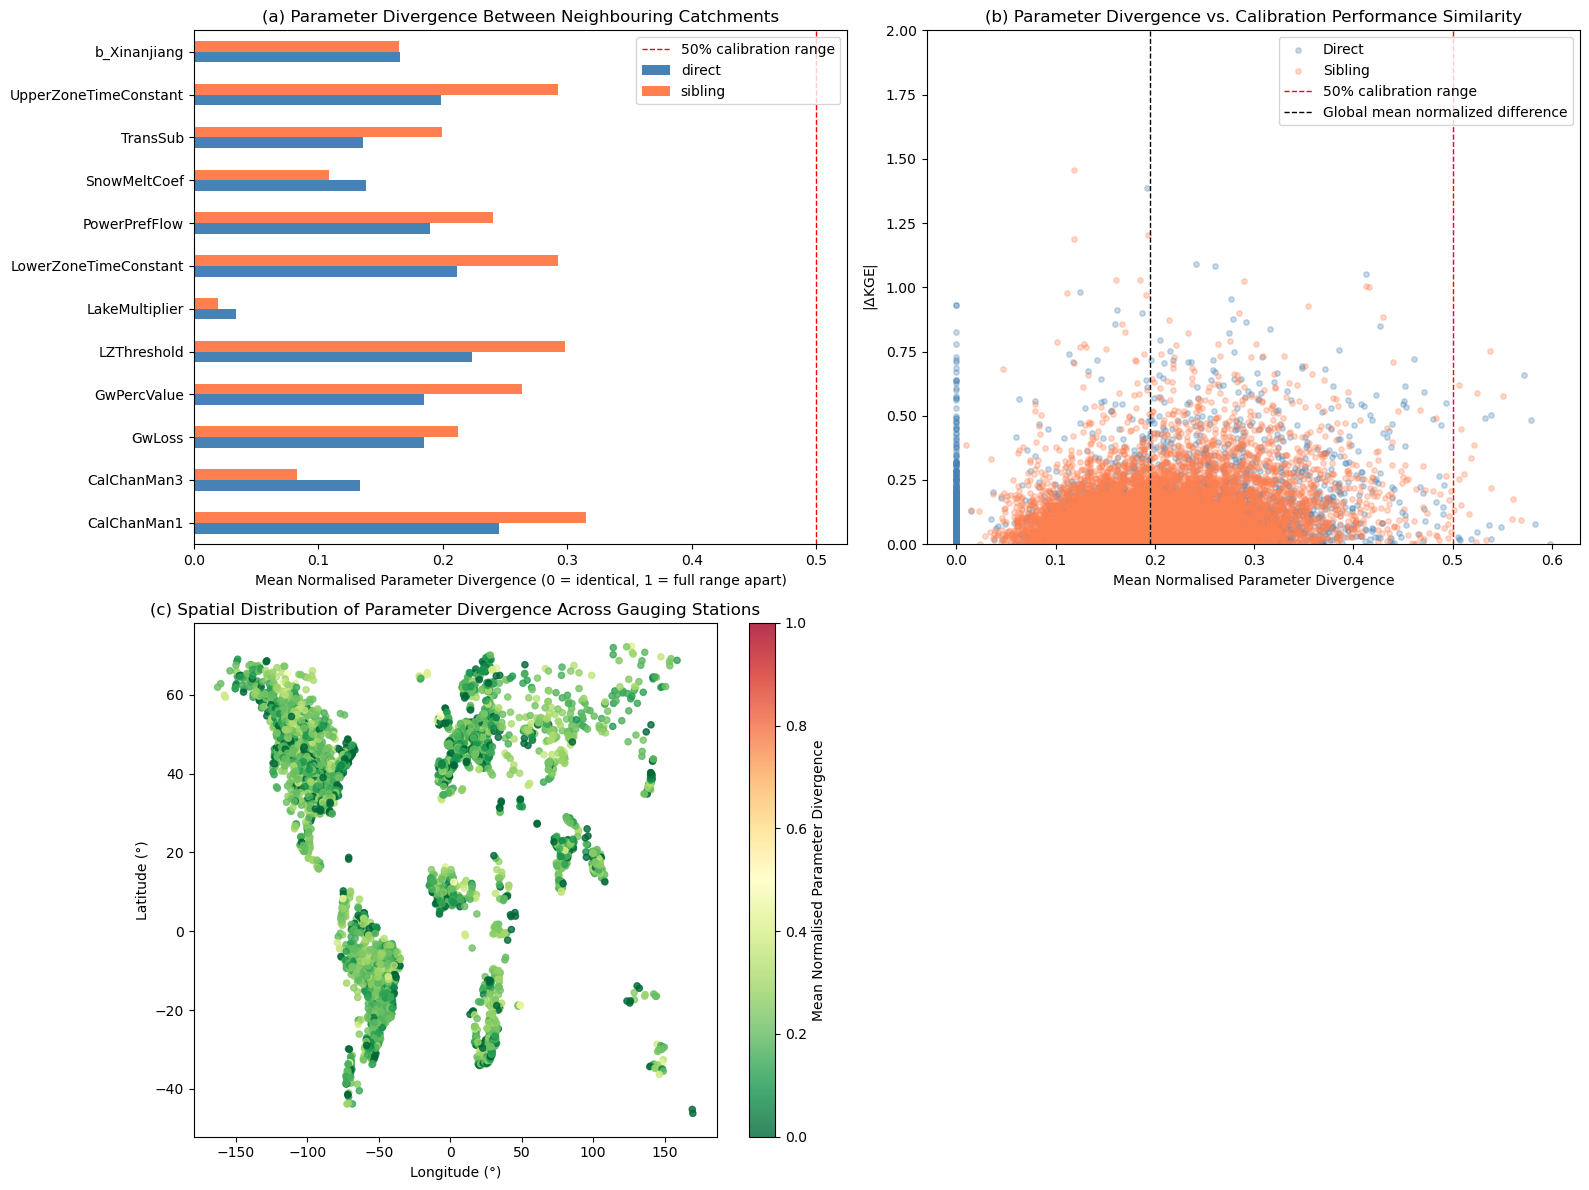

In [56]:
# ─────────────────────────────────────────────
# PARAMETER RANGES & NORMIERUNG
# ─────────────────────────────────────────────

# NOTE: CalChanMan3 und LakeMultiplier nicht in offiziellen Ranges —
# verwenden hier empirische Min/Max aus den Stationsdaten.
# CalChanMan3 insbesondere klären: ist der ein eigenständiger Parameter
# oder identisch mit CalChanMan1?

param_ranges = {
    "param_UpperZoneTimeConstant" : (0.01, 40.0),
    "param_LowerZoneTimeConstant" : (40.0, 730.0),
    "param_GwPercValue"           : (0.01, 2.0),
    "param_LZThreshold"           : (0.0,  30.0),
    "param_b_Xinanjiang"          : (0.01, 5.0),
    "param_PowerPrefFlow"         : (0.5,  8.0),
    "param_SnowMeltCoef"          : (2.5,  6.5),
    "param_CalChanMan1"           : (0.5,  5.0),
    # GwLoss und TransSub: prüfen ob hardkodiert
    # → wird unten automatisch entschieden
}

HARDCODED_THRESHOLD = 1e-6  # std < threshold → als hardkodiert betrachten

param_cols_all = [c for c in glofas5_base_info.columns if c.startswith("param_")]

# glofas_pars NC files aktuell ohne Funktion — Parameter kommen aus glofas5_base_info
params_df = glofas5_base_info.set_index("ID")[param_cols_all].copy()

# Hardkodierte Parameter detektieren
param_stds = params_df.std()
hardcoded  = param_stds[param_stds < HARDCODED_THRESHOLD].index.tolist()
active     = [p for p in param_cols_all if p not in hardcoded]

print("Hardkodierte Parameter (std ≈ 0, werden ignoriert):")
for p in hardcoded:
    print(f"  {p}: mean={params_df[p].mean():.6f}, std={param_stds[p]:.2e}")

print(f"\nAktive Parameter ({len(active)}): {active}")

# Ranges für CalChanMan3 und LakeMultiplier empirisch bestimmen
for p in active:
    if p not in param_ranges:
        pmin, pmax = params_df[p].min(), params_df[p].max()
        param_ranges[p] = (pmin, pmax)
        print(f"  Empirische Range für {p}: ({pmin:.4f}, {pmax:.4f})  ← klären!")

# ─────────────────────────────────────────────
# DIVERGENZ MIT RANGE-NORMIERUNG
# ─────────────────────────────────────────────

def compute_divergence_rangenorm(downstream, siblings, params_df, stations_df, param_ranges, active_params):
    """
    Divergenz normiert auf Kalibrierungs-Range:
    diff_norm = |p_a - p_b| / (p_max - p_min)
    → 0 = identisch, 1 = volle Range auseinander
    """
    ua_lookup = stations_df.set_index("station_id")["_uparea"]
    kge_lookup = glofas5_base_info.set_index("ID")["KGEmod"] \
        if "KGEmod" in glofas5_base_info.columns else None

    def param_divergence(id_a, id_b):
        diffs = {}
        for p in active_params:
            if p not in params_df.columns:
                continue
            pmin, pmax = param_ranges[p]
            prange = pmax - pmin
            if prange < 1e-9:
                continue
            diffs[f"ndiff_{p}"] = abs(params_df.loc[id_a, p] - params_df.loc[id_b, p]) / prange
        return diffs

    records = []

    # Direkte Paare
    for up_id, down_id in downstream.items():
        if down_id is None:
            continue
        if up_id not in params_df.index or down_id not in params_df.index:
            continue
        diffs = param_divergence(up_id, down_id)
        if not diffs:
            continue
        records.append({
            "station_a"  : up_id,
            "station_b"  : down_id,
            "pair_type"  : "direct",
            "uparea_a"   : ua_lookup.get(up_id, np.nan),
            "uparea_b"   : ua_lookup.get(down_id, np.nan),
            "kge_a"      : kge_lookup[up_id]   if kge_lookup is not None else np.nan,
            "kge_b"      : kge_lookup[down_id] if kge_lookup is not None else np.nan,
            "mean_ndiff" : np.mean(list(diffs.values())),
            **diffs,
        })

    # Sibling Paare
    from itertools import combinations
    for down_id, up_list in siblings.items():
        if len(up_list) < 2:
            continue
        for sib_a, sib_b in combinations(up_list, 2):
            if sib_a not in params_df.index or sib_b not in params_df.index:
                continue
            diffs = param_divergence(sib_a, sib_b)
            if not diffs:
                continue
            records.append({
                "station_a"  : sib_a,
                "station_b"  : sib_b,
                "pair_type"  : "sibling",
                "uparea_a"   : ua_lookup.get(sib_a, np.nan),
                "uparea_b"   : ua_lookup.get(sib_b, np.nan),
                "kge_a"      : kge_lookup[sib_a] if kge_lookup is not None else np.nan,
                "kge_b"      : kge_lookup[sib_b] if kge_lookup is not None else np.nan,
                "mean_ndiff" : np.mean(list(diffs.values())),
                **diffs,
            })

    return pd.DataFrame(records).sort_values("mean_ndiff", ascending=False)

divergence_df = compute_divergence_rangenorm(
    downstream, siblings, params_df, stations_df, param_ranges, active
)

print(f"\nPaare gesamt : {len(divergence_df)}")
print(f"  direkt     : {(divergence_df.pair_type == 'direct').sum()}")
print(f"  siblings   : {(divergence_df.pair_type == 'sibling').sum()}")
print(divergence_df[["station_a","station_b","pair_type","mean_ndiff","kge_a","kge_b"]].head(10))

divergence_df.to_csv(DIR_OUT / "equifinality_diagnosis_rangenorm.csv", index=False)

# ─────────────────────────────────────────────
# VISUALISIERUNG
# ─────────────────────────────────────────────

ndiff_cols = [c for c in divergence_df.columns if c.startswith("ndiff_")]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── Plot 1: Global Parameter Coherence ──
mean_per_param = divergence_df.groupby("pair_type")[ndiff_cols].mean().T
mean_per_param.index = [c.replace("ndiff_param_", "") for c in mean_per_param.index]
mean_per_param.plot.barh(ax=axes[0, 0], color=["steelblue", "coral"])
axes[0, 0].axvline(0.5, color="red", linestyle="--", linewidth=1, label="50% calibration range")
axes[0, 0].set_xlabel("Mean Normalised Parameter Divergence (0 = identical, 1 = full range apart)")
axes[0, 0].set_title("(a) Parameter Divergence Between Neighbouring Catchments")
axes[0, 0].legend()

# ── Plot 2: Equifinality Scatter ──
ax = axes[0, 1]
for ptype, color in [("direct", "steelblue"), ("sibling", "coral")]:
    sub = divergence_df[divergence_df.pair_type == ptype]
    kge_diff = (sub["kge_a"] - sub["kge_b"]).abs()
    ax.scatter(sub["mean_ndiff"], kge_diff,
               alpha=0.3, s=15, color=color, label=ptype.capitalize())
ax.axvline(0.5, color="red", linestyle="--", linewidth=1, label="50% calibration range")
ax.axvline(divergence_df["mean_ndiff"].mean(), color="k", linestyle="--", linewidth=1, label="Global mean normalized difference")
ax.set_xlabel("Mean Normalised Parameter Divergence")
ax.set_ylabel(r"$|\Delta \mathrm{KGE}|$")
ax.set_title("(b) Parameter Divergence vs. Calibration Performance Similarity")
ax.legend()
ax.set_ylim(0,2)

# ── Plot 3: Spatial Map ──
station_divergence = pd.concat([
    divergence_df[["station_a", "mean_ndiff"]].rename(columns={"station_a": "station_id"}),
    divergence_df[["station_b", "mean_ndiff"]].rename(columns={"station_b": "station_id"}),
]).groupby("station_id")["mean_ndiff"].mean()
map_df = stations_df.set_index("station_id").copy()
map_df["mean_ndiff"] = station_divergence

ax = axes[1, 0]
sc = ax.scatter(map_df["lon"], map_df["lat"],
                c=map_df["mean_ndiff"], cmap="RdYlGn_r",
                s=20, vmin=0, vmax=1, alpha=0.8)
plt.colorbar(sc, ax=ax, label="Mean Normalised Parameter Divergence")
ax.set_title("(c) Spatial Distribution of Parameter Divergence Across Gauging Stations")
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")

# ── Plot 4: empty ──
axes[1, 1].set_visible(False)

plt.tight_layout()
plt.savefig(DIR_OUT / "equifinality_diagnosis.png", dpi=250, bbox_inches="tight")


In [57]:
divergence_df.head()

,station_a,station_b,pair_type,uparea_a,uparea_b,kge_a,kge_b,mean_ndiff,ndiff_param_CalChanMan1,ndiff_param_CalChanMan3,ndiff_param_GwLoss,ndiff_param_GwPercValue,ndiff_param_LZThreshold,ndiff_param_LakeMultiplier,ndiff_param_LowerZoneTimeConstant,ndiff_param_PowerPrefFlow,ndiff_param_SnowMeltCoef,ndiff_param_TransSub,ndiff_param_UpperZoneTimeConstant,ndiff_param_b_Xinanjiang
2995,5507.0,5494.0,direct,1.557713e+10,1.299130e+12,0.788484,0.786123,0.598384,0.523351,0.996238,0.486353,0.153803,0.455264,0.897732,0.969933,0.835057,0.837360,0.106530,0.284734,0.634255
4000,5521.0,5494.0,direct,6.062374e+11,1.299130e+12,0.866136,0.786123,0.583114,0.963853,0.688384,0.920754,0.217332,0.231540,0.994131,0.391690,0.820780,0.333655,0.116643,0.492993,0.825619
1801,16567.0,5494.0,direct,3.793335e+09,1.299130e+12,0.304095,0.786123,0.578630,0.043636,0.998669,0.996720,0.279954,0.047887,0.666667,0.775790,0.780406,0.840362,0.099885,0.509507,0.904074
2730,5483.0,5494.0,direct,1.095601e+10,1.299130e+12,0.127627,0.786123,0.571646,0.959318,0.111111,0.998010,0.271899,0.429167,0.666667,0.253821,0.813637,0.802140,0.095228,0.509507,0.949251
9097,5507.0,5479.0,sibling,1.557713e+10,2.697133e+10,0.788484,0.881382,0.569128,0.493768,0.991646,0.020677,0.245909,0.475364,0.897732,0.665484,0.765913,0.872080,0.011388,0.734698,0.654880
